# ML Algorithms from Scratch

This notebook is for creating Linear Regression algorithms from scratch and testing them on California housing dataset.

## Libraries 

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

## Optimizers

In [23]:
def gradient():
    pass
def loss():
    pass


def mini_batch_GD(X_train, y_train, B=32, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)
    
    loss_ = []
    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    for epoch in range(epochs):

        indices = rng.permutation(n_samples)
        for start in range(0, n_samples, B):

            batch_indices = indices[start: start + B]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            
            grad_w, grad_b = gradient(X_batch, y_batch, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        loss_.append(loss(X_train, y_train, w_, b))
        

    return loss_, w_, b


def mini_batch_GD_val(X_train, y_train, X_val, y_val, B=32, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)
    
    loss_ = []
    val_loss_ = []

    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    patience = 20
    patience_counter = 0
    best_val_loss = float("inf")
    stop_epoch = epochs
    best_w_ = w_.copy()
    best_b = b
    
    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        for start in range(0, n_samples, B):
        
            batch_indices = indices[start: start + B]
            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]
            
            grad_w, grad_b = gradient(X_batch, y_batch, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        val_loss = loss(X_val, y_val, w_, b)

        loss_.append(loss(X_train, y_train, w_, b))
        val_loss_.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w_ = w_.copy()
            best_b = b
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            stop_epoch = epoch + 1
            break
        

    return stop_epoch, best_val_loss, val_loss_, loss_, best_w_, best_b


def SGD(X, y, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X.shape

    rng = np.random.default_rng(random_state)

    loss_ = []
    parameters = rng.normal(loc=0.0, scale=0.1, size = X.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]

    for _ in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n_samples):
            x_i = X_shuffled[i: i+1]
            y_i = y_shuffled[i: i+1]

            grad_w, grad_b = gradient(x_i, y_i, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        loss_.append(loss(X, y, w_, b))

    return loss_, w_, b

def SGD_val(X_train, y_train, X_val, y_val, eta=0.01, epochs=100, random_state=1):
    n_samples, n_features = X_train.shape

    rng = np.random.default_rng(random_state)

    loss_ = []
    val_loss_ = []

    parameters = rng.normal(loc=0.0, scale=0.1, size = X_train.shape[1] + 1)
    b, w_ = parameters[0], parameters[1:]


    patience = 20
    patience_counter = 0
    best_val_loss = float("inf")
    stop_epoch = epochs
    best_w_ = w_.copy()
    best_b = b
    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for i in range(n_samples):
            x_i = X_shuffled[i: i+1]
            y_i = y_shuffled[i: i+1]

            grad_w, grad_b = gradient(x_i, y_i, w_, b)
            w_ -= eta * grad_w
            b -= eta * grad_b

        val_loss = loss(X_val, y_val, w_, b)
        
        loss_.append(loss(X_train, y_train, w_, b))
        val_loss_.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_w_ = w_.copy()
            best_b = b
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            stop_epoch = epoch + 1
            break

    return stop_epoch, best_val_loss, val_loss_, loss_, best_w_, best_b


def normal_equation_fit(X, y):
    Xb = np.c_[np.ones(len(X)), X]

    # Better than explicitly computing inverse
    w_ = np.linalg.lstsq(Xb, y, rcond=None)[0]

    return w_[0], w_[1:]

    

## Helper functions

In [24]:

def net_input(X, w_, b):
    return X @ w_ + b

def max_eignvalue(X):
    H = (X.T @ X) / X.shape[0]
    eigenvalues = np.linalg.eigvalsh(H)
    return eigenvalues.max()

def predict(X, w_, b):
    return net_input(X, w_, b)

def loss(X, y, w_, b):
    errors = predict(X, w_, b) - y
    return 0.5 * np.mean(errors ** 2)

def gradient(X, y, w_, b):
    errors = predict(X, w_, b) - y

    grad_w = X.T @ errors / len(X)
    grad_b = np.mean(errors)

    return grad_w, grad_b


## Analysis and Visualization of Dataset

In [25]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

### 1. Geographical Map (Geospatial Analysis)

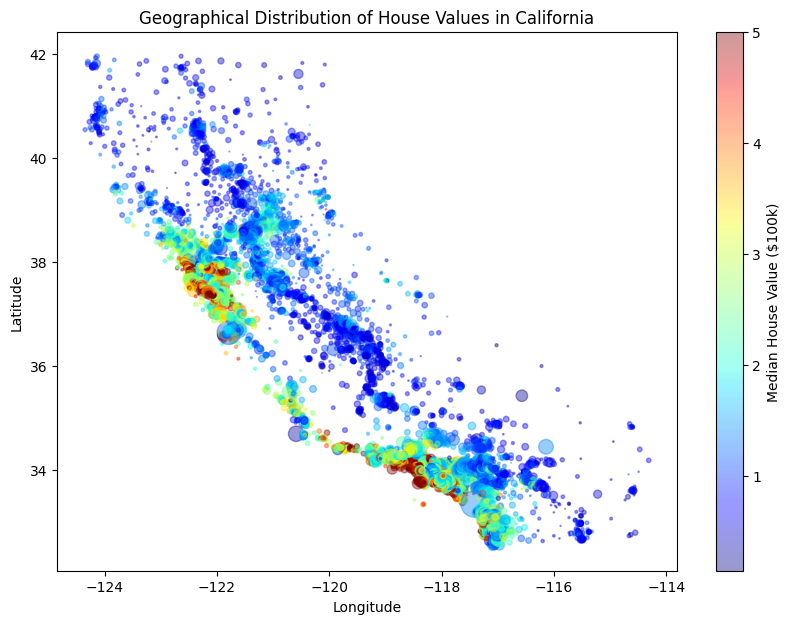

In [26]:
plt.figure(figsize=(10, 7))
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="jet",
    s=df["Population"] / 100,
    alpha=0.4,
)
plt.colorbar(label="Median House Value ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of House Values in California")
plt.show()

### 2. Feature Correlation Matrix

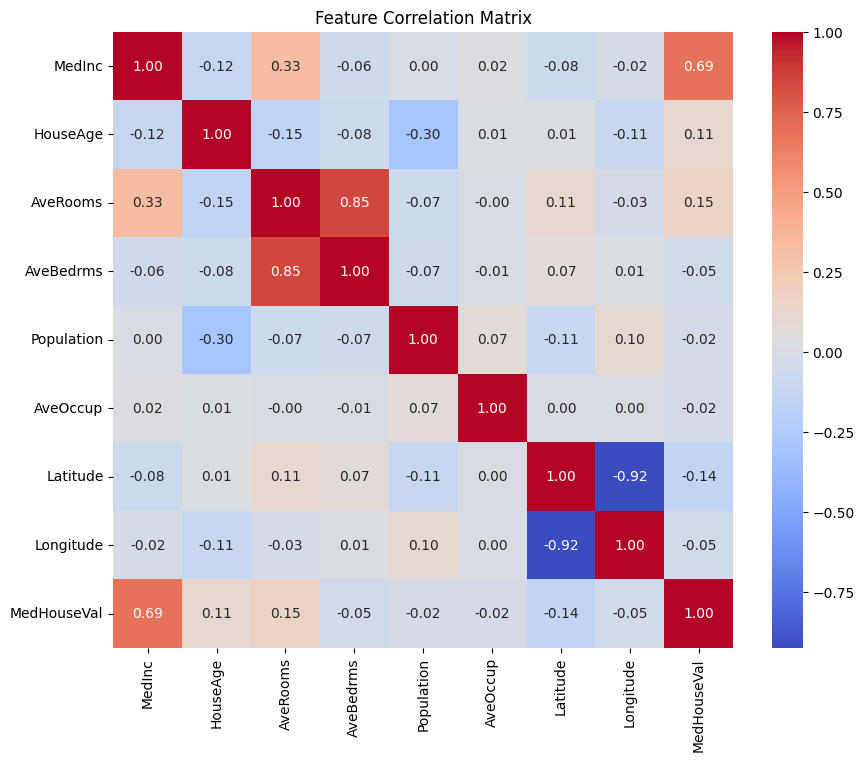

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

### 3. Target Distribution

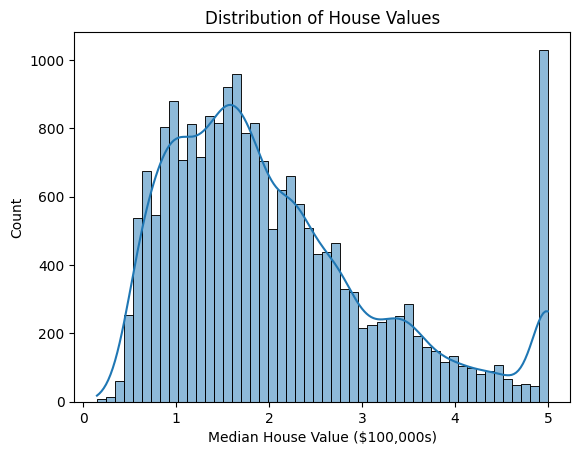

In [28]:
sns.histplot(df["MedHouseVal"], kde=True, bins=50)
plt.xlabel("Median House Value ($100,000s)")
plt.title("Distribution of House Values")
plt.show()

### 4. Income vs. House Price Relationship

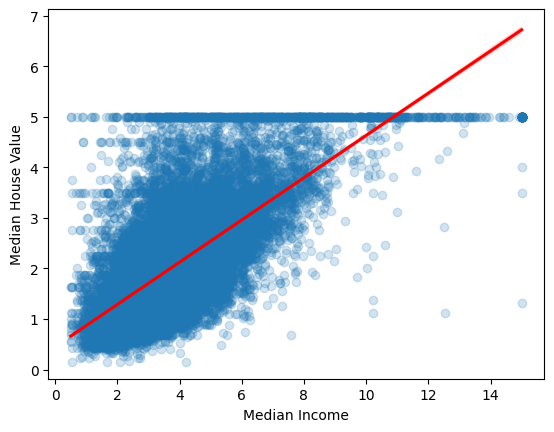

In [29]:
sns.regplot(
    x="MedInc",
    y="MedHouseVal",
    data=df,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"},
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

### 5. Outlier Detection for Structural Features

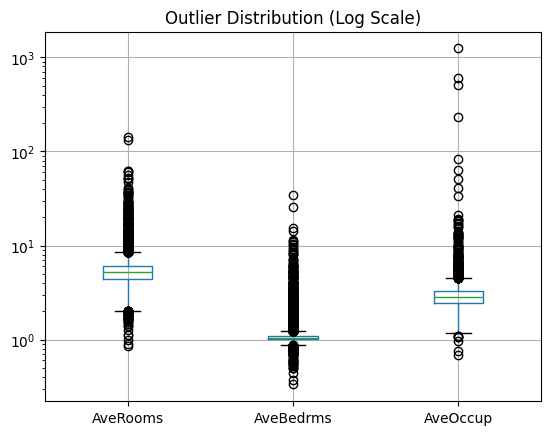

In [30]:
df[["AveRooms", "AveBedrms", "AveOccup"]].boxplot()
plt.yscale("log")  # Log scale helps display extreme outliers cleanly
plt.title("Outlier Distribution (Log Scale)")
plt.show()

## Linear Regression using Mini Batch Gradient descent

### 1. Clean and Split Dataset 

In [31]:
epochs = 1000

output_dir = Path("plots/california_housing")
output_dir.mkdir(parents=True, exist_ok=True)  # Creates the directory if it doesn't exist

X, y = fetch_california_housing(return_X_y=True)

# Standardize input features
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

mask = y < np.max(y)
X_clean = X_scaled[mask]
y_clean = y[mask]

X_train_val, X_test, y_train_val, y_test = train_test_split(X_clean, y_clean, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25)


### 2. Train Models

In [32]:
def run_experiment(optimizer, X_train, y_train, X_val, y_val, X_test, y_test,
                   etas, epochs, seeds=(42, 123, 99), output_dir=None):    
    results = []
    for eta in etas:
        # train and store losses from 3 different seeds
        train_losses = []
        val_losses = []
        test_losses = []
        stop_epochs = []

        
        weight_list = []
        bias_list = []

        for seed in seeds:
            np.random.seed(seed)

            stop_epoch, val_loss, val_loss_, loss_, weight_, bias = (
            
                optimizer(
                    X_train,
                    y_train,
                    X_val=X_val,
                    y_val=y_val,
                    eta=eta,
                    epochs=epochs
                )
            )

            test_loss = loss(X_test, y_test, weight_, bias)

            train_losses.append(loss_[-1])
            val_losses.append(val_loss)
            test_losses.append(test_loss)
            stop_epochs.append(stop_epoch)
            weight_list.append(weight_)
            bias_list.append(bias)

            # Plot
            if output_dir is not None:

                file_path = output_dir / f"eta_{eta}_seed_{seed}.png"
                epochs_ = np.arange(stop_epoch)
                plt.figure()  # Create a fresh figure for each iteration
                plt.plot(
                    epochs_,
                    loss_,
                    color="blue",
                    linewidth=1,
                    label="training loss"
                )
                plt.plot(
                    epochs_,
                    val_loss_,
                    linewidth=1,
                    label="validation loss"
                )

                plt.title("Learning Curve")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.legend()

                plt.savefig(
                    file_path,
                    bbox_inches="tight",
                    dpi=300
                )
                plt.close()  # Close the plot to free memory and avoid line overlap


        # Best seed according to validation loss
            best_seed_idx = np.argmin(val_losses)

        results.append(
            {
                "eta": eta,
                "mean train loss": np.mean(train_losses),
                "mean val loss": np.mean(val_losses),
                "mean test loss": np.mean(test_losses),
                "std train loss": np.std(train_losses),
                "std val loss": np.std(val_losses),
                "std test loss": np.std(test_losses),
                "avg # of epoch": np.mean(stop_epochs),
                "best weights": weight_list[best_seed_idx],
                "best bias": bias_list[best_seed_idx]
            }
        )

    return results

In [33]:
eta_max = 2 / max_eignvalue(X_train)
etas = np.logspace(-4, -1, 15)

results_mini_batch = run_experiment(
    mini_batch_GD_val,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    etas,
    epochs,
    output_dir = output_dir
)



### 3. Evaluate Models

In [34]:
bias_truth, weight_truth = normal_equation_fit(X_train, y_train)
loss_truth = loss(X_train, y_train, weight_truth, bias_truth)

print("Ground Truth Loss:", loss_truth)
print("Training X:", X_clean.shape)
print("Range of Y:",np.min(y), np.max(y))
print("max learning rate:", eta_max)
print("\n")


df_result = pd.DataFrame(results_mini_batch)
df_result_sorted = df_result.sort_values(by="mean val loss").reset_index(drop=True)

best_model = df_result_sorted.iloc[0]
best_weight_ = best_model["best weights"]
best_bias = best_model["best bias"]

df_result_sorted.drop(columns=["best weights", "best bias"], inplace=True)
print("mini-batch Gradient Descent:\n")
print(df_result_sorted.to_string())



Ground Truth Loss: 0.2075301886527292
Training X: (19675, 8)
Range of Y: 0.14999 5.00001
max learning rate: 1.0055680300084968


mini-batch Gradient Descent:

         eta  mean train loss  mean val loss  mean test loss  std train loss  std val loss  std test loss  avg # of epoch
0   0.003162     2.075807e-01       0.194100        0.211285    0.000000e+00  0.000000e+00   0.000000e+00            70.0
1   0.001931     2.075424e-01       0.194163        0.210883    0.000000e+00  0.000000e+00   2.775558e-17           118.0
2   0.001179     2.075493e-01       0.194206        0.210530    0.000000e+00  0.000000e+00   0.000000e+00           162.0
3   0.000720     2.075467e-01       0.194250        0.210499    0.000000e+00  2.775558e-17   0.000000e+00           263.0
4   0.000439     2.075772e-01       0.194279        0.210315    2.775558e-17  0.000000e+00   0.000000e+00           353.0
5   0.000268     2.075883e-01       0.194297        0.210245    2.775558e-17  0.000000e+00   0.000000e+00    

### 4. Best Pick

Training R2 Score: 0.5663459418335393
Validation R2 Score: 0.5806858568060436
Test R2 Score: 0.5662150394109456


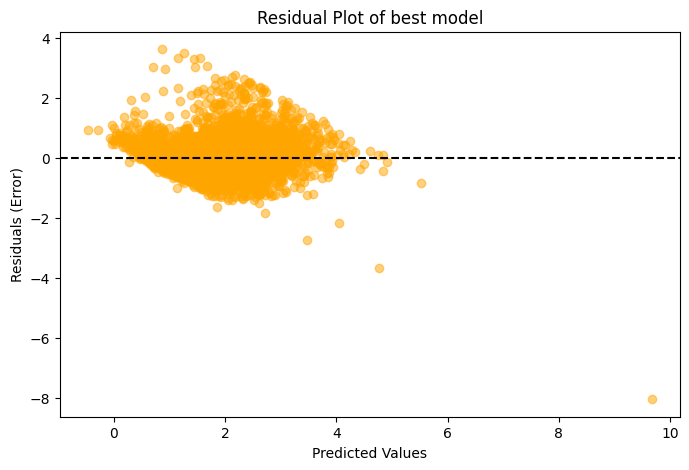

In [35]:
print("Training R2 Score:", r2_score(y_train, predict(X_train, best_weight_, best_bias)))
print("Validation R2 Score:", r2_score(y_val, predict(X_val, best_weight_, best_bias)))
print("Test R2 Score:", r2_score(y_test, predict(X_test, best_weight_, best_bias)))


y_pred = predict(X_test, best_weight_, best_bias)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="orange")
plt.axhline(0, color="black", linestyle="--")  # Zero error line

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot of best model")
plt.show()

### 5. Retrain Model on Train + Val Sets (Optional)

eta                   0.003162
train loss            0.204193
test loss             0.211145
Training R2 Score:    0.566526
test R2 score         0.566504
dtype: float64


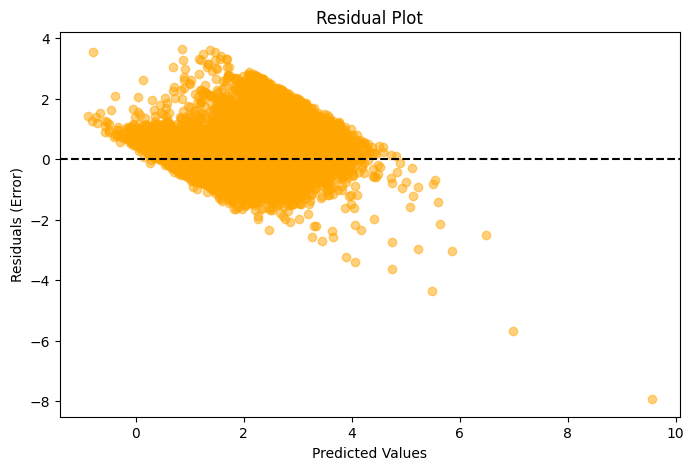

In [36]:
best_eta = df_result_sorted.iloc[0]["eta"]

loss_, weight_, bias = mini_batch_GD(X_train_val, y_train_val, eta=best_eta, epochs=epochs)
test_loss = loss(X_test, y_test, weight_, bias)

retrain_model = pd.Series({
    "eta": best_eta,
    "train loss": loss_[-1],
    "test loss": test_loss,
    "Training R2 Score:": r2_score(y_train, predict(X_train, weight_, bias)),
    "test R2 score": r2_score(y_test, predict(X_test, weight_, bias))

})
print(retrain_model)


y_pred = predict(X_clean, weight_, bias)
residuals = y_clean - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="orange")
plt.axhline(0, color="black", linestyle="--")  # Zero error line

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()



## Redo for Stochastic Gradient Descent

### Training

In [37]:
results_stochastic = run_experiment(
    SGD_val,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    etas,
    epochs,
    output_dir = output_dir
)


/var/folders/qz/487ytfw500zbvpswb1n12scc0000gn/T/ipykernel_78182/2845729186.py:14: RuntimeWarning: overflow encountered in square
  return 0.5 * np.mean(errors ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


### Evaluation

In [38]:
df_result = pd.DataFrame(results_stochastic)
df_result_sorted = df_result.sort_values(by="mean val loss").reset_index(drop=True)

best_model = df_result_sorted.iloc[0]
best_weight_ = best_model["best weights"]
best_bias = best_model["best bias"]

df_result_sorted.drop(columns=["best weights", "best bias"], inplace=True)
print("Stochastic Gradient Descent:\n")
print(df_result_sorted.to_string())

Stochastic Gradient Descent:

         eta  mean train loss  mean val loss  mean test loss  std train loss  std val loss  std test loss  avg # of epoch
0   0.000100     2.075795e-01   1.940995e-01    2.113177e-01             0.0  0.000000e+00   0.000000e+00            70.0
1   0.000164     7.882223e+02   2.264373e-01    2.355573e-01             0.0  2.775558e-17   2.775558e-17            24.0
2   0.000268     7.424842e+15   2.729127e-01    2.647799e-01             0.0  0.000000e+00   0.000000e+00            21.0
3   0.000439     9.293831e+26   3.700326e-01    3.095688e-01             0.0  5.551115e-17   0.000000e+00            21.0
4   0.000720     6.302696e+36   9.527170e-01    6.454421e-01             0.0  1.110223e-16   0.000000e+00            21.0
5   0.001179     4.824898e+45   4.198087e+00    2.578939e+00             0.0  0.000000e+00   0.000000e+00            21.0
6   0.001931     3.410734e+53   2.195219e+01    1.324790e+01             0.0  3.552714e-15   0.000000e+00           

### Best Pick

Training R2 Score: 0.5663400701086772
Validation R2 Score: 0.5806860784314529
Test R2 Score: 0.5661487972051366


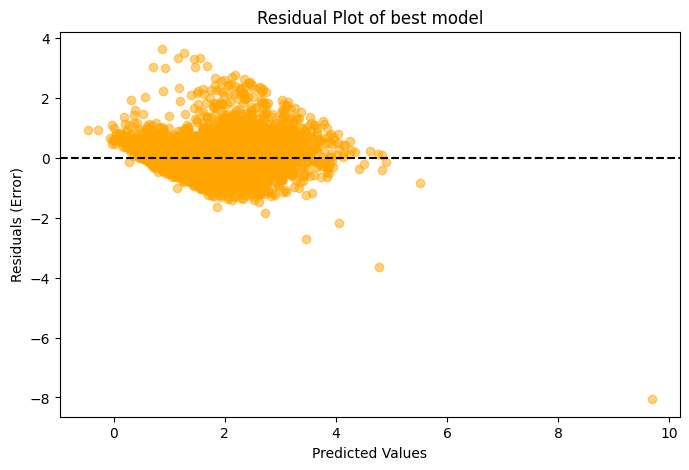

In [39]:
print("Training R2 Score:", r2_score(y_train, predict(X_train, best_weight_, best_bias)))
print("Validation R2 Score:", r2_score(y_val, predict(X_val, best_weight_, best_bias)))
print("Test R2 Score:", r2_score(y_test, predict(X_test, best_weight_, best_bias)))


y_pred = predict(X_test, best_weight_, best_bias)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="orange")
plt.axhline(0, color="black", linestyle="--")  # Zero error line

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot of best model")
plt.show()

### Retrain (Optional)

eta                   0.000100
train loss            0.204194
test loss             0.211141
Training R2 Score:    0.566527
test R2 score         0.566512
dtype: float64


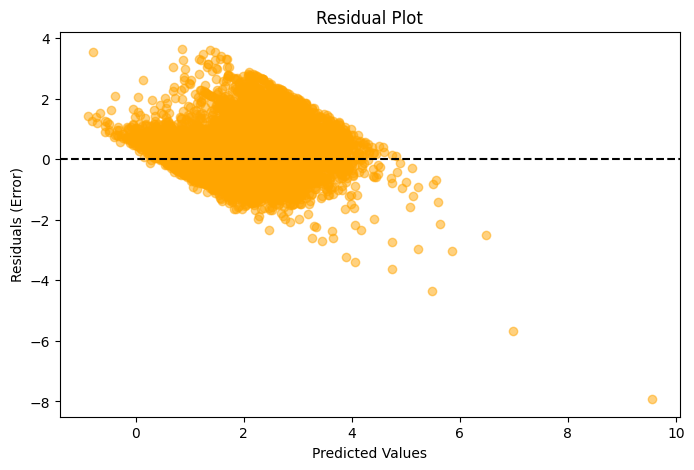

In [40]:
best_eta = df_result_sorted.iloc[0]["eta"]

loss_, weight_, bias = SGD(X_train_val, y_train_val, eta=best_eta, epochs=epochs)
test_loss = loss(X_test, y_test, weight_, bias)

retrain_model = pd.Series({
    "eta": best_eta,
    "train loss": loss_[-1],
    "test loss": test_loss,
    "Training R2 Score:": r2_score(y_train, predict(X_train, weight_, bias)),
    "test R2 score": r2_score(y_test, predict(X_test, weight_, bias))

})
print(retrain_model)


y_pred = predict(X_clean, weight_, bias)
residuals = y_clean - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="orange")
plt.axhline(0, color="black", linestyle="--")  # Zero error line

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()